In [17]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, precision_recall_curve
)

In [18]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/finalized_v2.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588912 entries, 0 to 588911
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   is_fraud                 588912 non-null  int64  
 1   card_type                588912 non-null  object 
 2   purchaser_email_domain   588912 non-null  object 
 3   device_type              588912 non-null  object 
 4   is_identity_seen_before  588912 non-null  float64
 5   user_os                  588912 non-null  object 
 6   user_browser             588912 non-null  object 
 7   environment_risk         588912 non-null  float64
 8   card_info                588912 non-null  object 
 9   time_hour                588912 non-null  int64  
 10  amt_bins                 588912 non-null  int64  
 11  day_of_week              588912 non-null  int64  
 12  time_diff_log            588912 non-null  float64
 13  amt_log                  588912 non-null  float64
 14  time

In [19]:
df['is_identity_seen_before'].unique()
df['environment_risk'].unique()

array([0., 1., 2.])

In [20]:
df['is_identity_seen_before'] = df['is_identity_seen_before'].map(
    {'New': 0, 'Found': 1}
).fillna(2)

df['environment_risk'] = df['environment_risk'].fillna(0)

print(df['environment_risk'].unique())
print(df['is_identity_seen_before'].unique())


[0. 1. 2.]
[2.]


In [21]:
# importing all base models
rf_model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/model_v4_rf.pkl')
lgb_model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/model_v4_lgb.pkl')
xg_model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/model_v4_xg.pkl')
lr_model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/model_v4_lr.pkl')

# OOF scores (cv_proba)
rf_proba = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/cv_proba_v4_rf.pkl')
lgb_proba = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/cv_proba_v4_lgb.pkl')
xg_proba = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/cv_proba_v4_xg.pkl')
lr_proba = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/cv_proba_v4_lr.pkl')

rf_test = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/rf_proba_test.pkl')
lgb_test = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/lgb_proba_test.pkl')
xg_test = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/xg_proba_test.pkl')
lr_test = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/lr_proba_test.pkl')

/home/prince/anaconda3/lib/python3.13/pickle.py:1760: UserWarning: [19:27:31] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:402: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/home/prince/anaconda3/lib/python3.13/pickle.py:1760: UserWarning: [19:27:31] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  setstate(state)
/home/prince/anaconda3/lib/python3.13/pickle.py:1760: UserWarning: [19:27:31] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)


In [22]:
label      = df['is_fraud'].astype(int)
predictors = df.drop(columns=['is_fraud'])

x_train, x_test, y_train, y_test = train_test_split(
    predictors, label, test_size=0.2, random_state=42, stratify=label
)
y_train = y_train.astype(int)
y_test  = y_test.astype(int)

In [23]:
base_data = pd.DataFrame({
    'rf'           : rf_proba,
    'lgb'          : lgb_proba,
    'xg'           : xg_proba,
    'lr'           : lr_proba,
    'env_risk'     : x_train['environment_risk'].values,
    'id_seen'      : x_train['is_identity_seen_before'].values,
    'time_hr'      : x_train['time_hour'].values,
    'amt_log'      : x_train['amt_log'].values,
    'time_diff_log': x_train['time_diff_log'].values,
}, index=range(471129))

# Build meta features for test — same structure as base_data
base_data_test = pd.DataFrame({
    'rf'           : rf_test,
    'lgb'          : lgb_test,
    'xg'           : xg_test,
    'lr'           : lr_test,
    'env_risk'     : x_test['environment_risk'].values,
    'id_seen'      : x_test['is_identity_seen_before'].values,
    'time_hr'      : x_test['time_hour'].values,
    'amt_log'      : x_test['amt_log'].values,
    'time_diff_log': x_test['time_diff_log'].values,
})

In [24]:
# columns that need scaling in meta layer
scale_cols  = ['amt_log', 'time_diff_log']
# columns that are already 0-1 or ordinal — no scaling needed
pass_cols   = ['rf', 'lgb', 'xg', 'lr', 'env_risk', 'id_seen', 'time_hr']

meta_preprocessor = ColumnTransformer([
    ('scale',    StandardScaler(), scale_cols),
    ('passthrough', 'passthrough', pass_cols)
])

meta_pipeline = Pipeline([
    ('preprocessor', meta_preprocessor),
    ('meta_model',   LogisticRegression(
                        class_weight = 'balanced',
                        max_iter     = 1000,
                        random_state = 42
                    ))
])

# Train
meta_pipeline.fit(base_data, y_train)

# Evaluate on test
meta_test_proba = meta_pipeline.predict_proba(base_data_test)[:, 1]
meta_test_pred  = (meta_test_proba >= 0.5).astype(int)

print(classification_report(y_test, meta_test_pred))

              precision    recall  f1-score   support

           0       0.98      0.81      0.89    113659
           1       0.11      0.65      0.19      4124

    accuracy                           0.80    117783
   macro avg       0.55      0.73      0.54    117783
weighted avg       0.95      0.80      0.86    117783



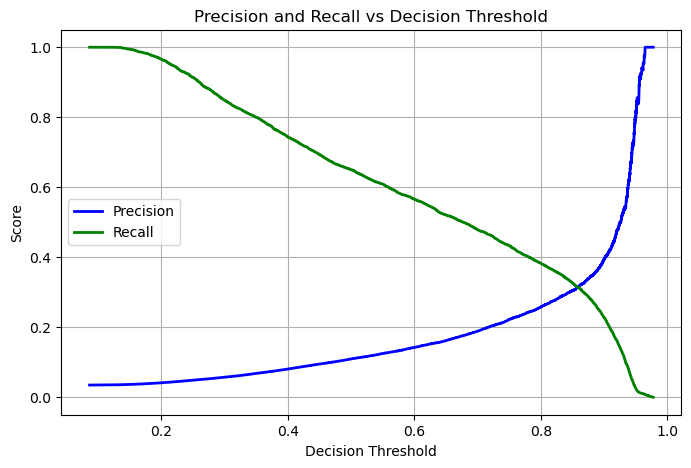

In [29]:
meta_proba = meta_pipeline.predict_proba(base_data)[:, 1]
meta_pred  = (meta_proba >= 0.5).astype(int)

precision, recall, threshold = precision_recall_curve(y_test, meta_test_proba, pos_label=1)
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

# Precision vs threshold
plt.plot(threshold, precision[:-1], "b-", linewidth=2, label="Precision")

# Recall vs threshold
plt.plot(threshold, recall[:-1], "g-", linewidth=2, label="Recall")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Decision Threshold")

plt.legend()
plt.grid(True)

plt.show()

In [30]:
print(classification_report(y_train, meta_pred))

              precision    recall  f1-score   support

           0       0.98      0.80      0.88    454631
           1       0.10      0.65      0.18     16498

    accuracy                           0.79    471129
   macro avg       0.54      0.73      0.53    471129
weighted avg       0.95      0.79      0.86    471129



In [32]:
# Use meta model on meta features, not raw x_train
meta_train_proba = meta_pipeline.predict_proba(base_data)[:, 1]
meta_test_proba  = meta_pipeline.predict_proba(base_data_test)[:, 1]

# Optional: explore per-group distributions (train only)
fraud_probs = meta_train_proba[y_train == 1]
nonfraud_probs = meta_train_proba[y_train == 0]

print('meta train fraud probs:', fraud_probs.shape, 'nonfraud:', nonfraud_probs.shape)
print('done')

meta train fraud probs: (16498,) nonfraud: (454631,)
done


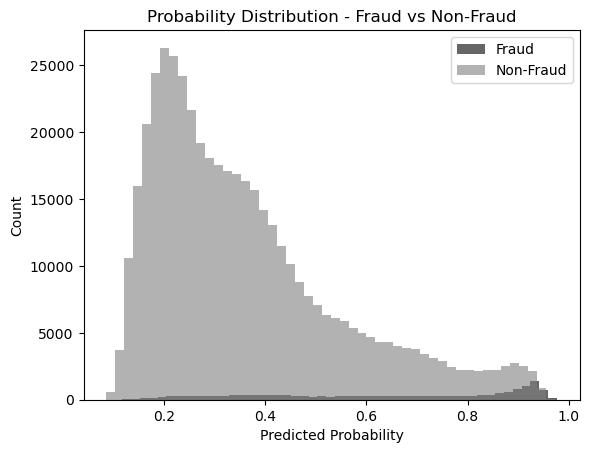

In [33]:
plt.hist(fraud_probs, bins=50, alpha=0.6, label='Fraud', color='black')
plt.hist(nonfraud_probs, bins=50, alpha=0.6, label='Non-Fraud', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Fraud vs Non-Fraud')
plt.legend()
# plt.ylim(0, 5000)
plt.show()

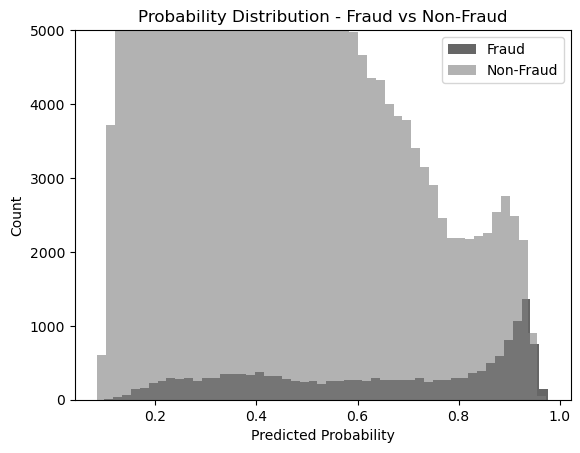

In [34]:
plt.hist(fraud_probs, bins=50, alpha=0.6, label='Fraud', color='black')
plt.hist(nonfraud_probs, bins=50, alpha=0.6, label='Non-Fraud', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Fraud vs Non-Fraud')
plt.legend()
plt.ylim(0, 5000)
plt.show()

In [35]:
print(f"Fraud Mean:      {fraud_probs.mean():.4f}")
print(f"Non-Fraud Mean:  {nonfraud_probs.mean():.4f}")
print(f"Gap:             {(fraud_probs.mean() - nonfraud_probs.mean()):.4f}")
print(f"Fraud Max:       {fraud_probs.max():.4f}")
print(f"Non Fraud min: {nonfraud_probs.min():.4f}")
print(f"Fraud Std:         {fraud_probs.std():.4f}")
print(f"Non-Fraud Std:     {nonfraud_probs.std():.4f}")

Fraud Mean:      0.6370
Non-Fraud Mean:  0.3630
Gap:             0.2740
Fraud Max:       0.9773
Non Fraud min: 0.0852
Fraud Std:         0.2535
Non-Fraud Std:     0.1896
